In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

# Ruta desde: TFG/SRC/notebook/notebook.ipynb
RUTA_DATASET_RAW = Path("../../DATA/RAW/lung_colon_image_set").resolve()

CLASES = {
    "lung_n": "Tejido benigno de pulmón",
    "lung_aca": "Adenocarcinoma de pulmón",
    "lung_scc": "Carcinoma escamoso de pulmón",
    "colon_n": "Tejido benigno de colon",
    "colon_aca": "Adenocarcinoma de colon",
}

CLAVES_CLASES = ["lung_n", "lung_aca", "lung_scc", "colon_n", "colon_aca"]

In [7]:
print("Ruta dataset:", RUTA_DATASET_RAW)
print("Existe:", RUTA_DATASET_RAW.exists())

Ruta dataset: C:\Users\Adri\Desktop\TFG\TFG\DATA\RAW\lung_colon_image_set
Existe: True


In [8]:
datos = []

for clase in CLAVES_CLASES:
    carpetas = list(RUTA_DATASET_RAW.rglob(clase))
    
    if not carpetas:
        print(f"No se encontró la clase: {clase}")
        continue
    
    ruta_clase = carpetas[0]
    
    imagenes = [
        img for img in ruta_clase.rglob("*")
        if img.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    
    datos.append({
        "Clase": clase,
        "Descripción": CLASES[clase],
        "Número de imágenes": len(imagenes)
    })

df_conteo = pd.DataFrame(datos)
df_conteo

,Clase,Descripción,Número de imágenes
0,lung_n,Tejido benigno de pulmón,5000
1,lung_aca,Adenocarcinoma de pulmón,5000
2,lung_scc,Carcinoma escamoso de pulmón,5000
3,colon_n,Tejido benigno de colon,5000
4,colon_aca,Adenocarcinoma de colon,5000


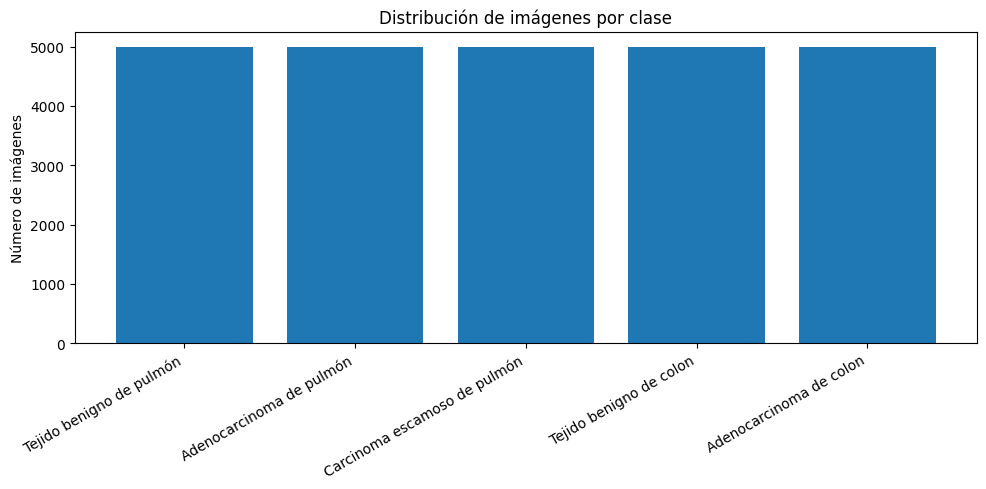

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(df_conteo["Descripción"], df_conteo["Número de imágenes"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Número de imágenes")
plt.title("Distribución de imágenes por clase")
plt.tight_layout()
plt.show()

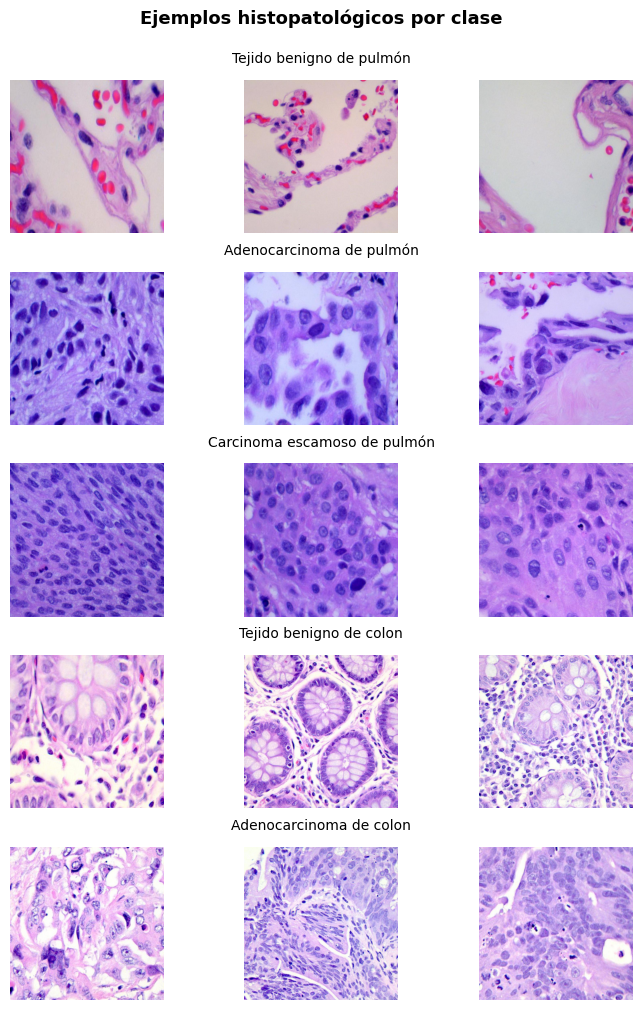

In [28]:
fig, axes = plt.subplots(5, 3, figsize=(7.5, 10))

for fila, clase in enumerate(CLAVES_CLASES):
    ruta_clase = list(RUTA_DATASET_RAW.rglob(clase))[0]
    
    imagenes = [
        img for img in ruta_clase.rglob("*")
        if img.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    
    muestras = random.sample(imagenes, 3)
    
    for col, img_path in enumerate(muestras):
        img = Image.open(img_path)
        axes[fila, col].imshow(img)
        axes[fila, col].axis("off")
    
    # Más separación del texto respecto a imágenes
    axes[fila, 1].set_title(
        CLASES[clase],
        fontsize=10,
        pad=12   # 🔥 clave: separa el texto de la imagen
    )

fig.suptitle(
    "Ejemplos histopatológicos por clase",
    fontsize=13,
    fontweight="bold",
    y=1.02
)

# 🔥 Ajuste fino de espacios
plt.subplots_adjust(
    top=0.95,
    bottom=0.03,
    left=0.04,
    right=0.96,
    hspace=0.25,   # 🔥 menos espacio entre imágenes (antes 0.45+)
    wspace=0.06    # 🔥 imágenes más juntas horizontalmente
)

plt.savefig(ruta_salida, dpi=300, bbox_inches="tight")
plt.show()